Dataset Shape: (3453, 2)


,Text,Sentiment
0,"According to Gran , the company has no plans t...",1
1,With the new production plant the company woul...,2
2,"For the last quarter of 2010 , Componenta 's n...",2
3,"In the third quarter of 2010 , net sales incre...",2
4,Operating profit rose to EUR 13.1 mn from EUR ...,2



Train Shape: (2762,)
Test Shape: (691,)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Starting Training...

======== Epoch 1/50 ========
Train Loss: 0.9553
Validation Loss: 0.8520
Train Accuracy: 62.31%
Validation Accuracy: 60.06%

Best model saved.

======== Epoch 2/50 ========
Train Loss: 0.6475
Validation Loss: 0.3721
Train Accuracy: 73.90%
Validation Accuracy: 88.86%

Best model saved.

======== Epoch 3/50 ========
Train Loss: 0.2816
Validation Loss: 0.2385
Train Accuracy: 91.46%
Validation Accuracy: 92.47%

Best model saved.

======== Epoch 4/50 ========
Train Loss: 0.1374
Validation Loss: 0.2170
Train Accuracy: 96.09%
Validation Accuracy: 93.20%

Best model saved.

======== Epoch 5/50 ========
Train Loss: 0.0858
Validation Loss: 0.2324
Train Accuracy: 97.83%
Validation Accuracy: 93.20%

======== Epoch 6/50 ========
Train Loss: 0.0471
Validation Loss: 0.2715
Train Accuracy: 98.88%
Validation Accuracy: 93.49%

Best model saved.

======== Epoch 7/50 ========
Train Loss: 0.0305
Validation Loss: 0.3308
Train Accuracy: 99.38%
Validation Accuracy: 93.05%

======== Epoch

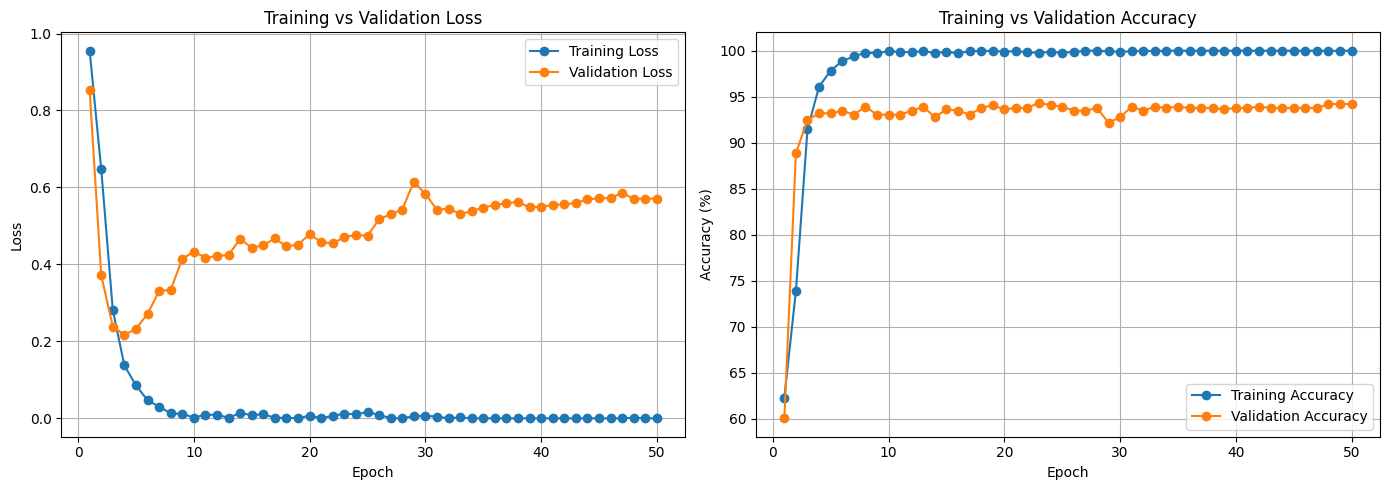


Classification Report:

              precision    recall  f1-score   support

Negative (0)       0.83      0.93      0.88        80
 Neutral (1)       0.98      0.96      0.97       415
Positive (2)       0.91      0.91      0.91       196

    accuracy                           0.94       691
   macro avg       0.91      0.93      0.92       691
weighted avg       0.94      0.94      0.94       691



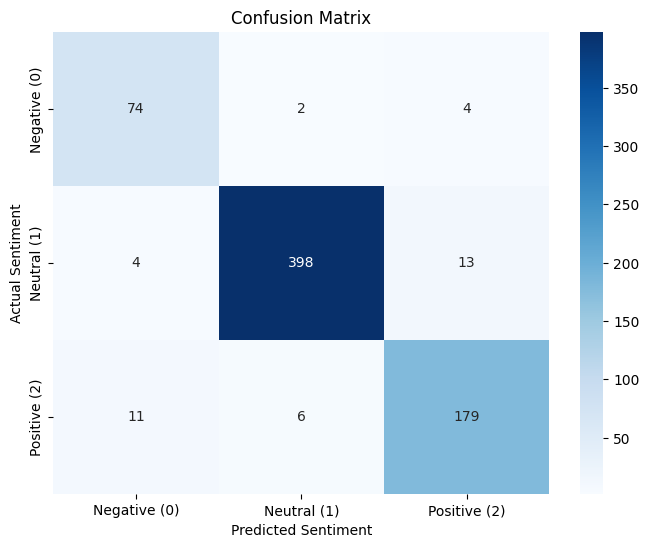


Final Accuracy: 94.21%


In [3]:
# !pip install torch transformers pandas numpy matplotlib seaborn scikit-learn

from transformers import BertTokenizer, BertModel
from transformers import get_linear_schedule_with_warmup

import torch
import torch.nn as nn

from torch.utils.data import (
    TensorDataset,
    DataLoader,
    RandomSampler,
    SequentialSampler
)

from torch.optim import AdamW

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

# ============================================================
# PREPROCESS FUNCTION
# ============================================================

def preprocess_tweets(data):

    data['Text_Cleaned'] = data['Text'].astype(str).str.lower()

    # Remove URLs
    data['Text_Cleaned'] = data['Text_Cleaned'].replace(
        r'https?:\/\/.*[\r\n]*',
        ' ',
        regex=True
    )

    data['Text_Cleaned'] = data['Text_Cleaned'].replace(
        r'www.*[\r\n]*',
        ' ',
        regex=True
    )

    # Remove mentions
    data['Text_Cleaned'] = data['Text_Cleaned'].replace(
        r'@[A-Za-z0-9_]+',
        '',
        regex=True
    )

    # Remove hashtags
    data['Text_Cleaned'] = data['Text_Cleaned'].replace(
        r'#[A-Za-z0-9_]+',
        '',
        regex=True
    )

    # Remove special characters
    data['Text_Cleaned'] = data['Text_Cleaned'].replace(
        r'[^a-zA-Z0-9\s]',
        ' ',
        regex=True
    )

    # Remove extra spaces
    data['Text_Cleaned'] = data['Text_Cleaned'].replace(
        r'\s+',
        ' ',
        regex=True
    )

    data['Text_Cleaned'] = data['Text_Cleaned'].str.strip()

    return data

# ============================================================
# LOAD FINANCIAL PHRASEBANK DATASET (.txt)
# ============================================================

texts = []
labels = []

with open('Sentences_75Agree.txt', 'r', encoding='latin-1') as f:

    for line in f:

        # POSITIVE
        if '@positive' in line:

            text = line.replace('@positive', '').strip()

            texts.append(text)

            labels.append(2)

        # NEUTRAL
        elif '@neutral' in line:

            text = line.replace('@neutral', '').strip()

            texts.append(text)

            labels.append(1)

        # NEGATIVE
        elif '@negative' in line:

            text = line.replace('@negative', '').strip()

            texts.append(text)

            labels.append(0)

# Create DataFrame
data = pd.DataFrame({
    'Text': texts,
    'Sentiment': labels
})

print("Dataset Shape:", data.shape)

display(data.head())

# ============================================================
# PREPROCESS DATA
# ============================================================

data = preprocess_tweets(data)

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

train_pct = 0.8

np.random.seed(1)

idx = np.random.permutation(len(data))

X_train = data['Text_Cleaned'].values[
    idx[:int(train_pct * len(data))]
]

y_train = data['Sentiment'].values[
    idx[:int(train_pct * len(data))]
]

X_test = data['Text_Cleaned'].values[
    idx[int(train_pct * len(data)):]
]

y_test = data['Sentiment'].values[
    idx[int(train_pct * len(data)):]
]

print("\nTrain Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

# ============================================================
# TOKENIZER
# ============================================================

tokenizer = BertTokenizer.from_pretrained(
    'bert-base-uncased',
    do_lower_case=True
)

MAX_LEN = 64

print("\nUsing MAX_LEN =", MAX_LEN)

# ============================================================
# TOKENIZATION FUNCTION
# ============================================================

def preprocessing_for_bert(data_col):

    input_ids = []
    attention_masks = []

    for text in data_col:

        encoding = tokenizer(
            text=text,
            add_special_tokens=True,
            max_length=MAX_LEN,
            truncation=True,
            padding='max_length',
            return_attention_mask=True,
            return_tensors='pt'
        )

        input_ids.append(encoding['input_ids'])

        attention_masks.append(
            encoding['attention_mask']
        )

    input_ids = torch.cat(input_ids, dim=0)

    attention_masks = torch.cat(
        attention_masks,
        dim=0
    )

    return input_ids, attention_masks

print("\nTokenizing Data...")

X_train_inputs, X_train_masks = preprocessing_for_bert(X_train)

X_test_inputs, X_test_masks = preprocessing_for_bert(X_test)

y_train_labels = torch.tensor(y_train)

y_test_labels = torch.tensor(y_test)

# ============================================================
# DATALOADERS
# ============================================================

batch_size = 16

train_data = TensorDataset(
    X_train_inputs,
    X_train_masks,
    y_train_labels
)

train_sampler = RandomSampler(train_data)

train_dataloader = DataLoader(
    train_data,
    sampler=train_sampler,
    batch_size=batch_size
)

test_data = TensorDataset(
    X_test_inputs,
    X_test_masks,
    y_test_labels
)

test_sampler = SequentialSampler(test_data)

test_dataloader = DataLoader(
    test_data,
    sampler=test_sampler,
    batch_size=batch_size
)

# ============================================================
# MODEL
# ============================================================

class BertClassifier(nn.Module):

    def __init__(self, freeze=False):

        super(BertClassifier, self).__init__()

        self.bert = BertModel.from_pretrained(
            'bert-base-uncased'
        )

        self.dropout = nn.Dropout(0.3)

        self.classifier = nn.Sequential(

            nn.Linear(768, 128),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(128, 3)

        )

        if freeze:

            for param in self.bert.parameters():

                param.requires_grad = False

    def forward(self, input_ids, attention_mask):

        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls_output = outputs.last_hidden_state[:, 0, :]

        cls_output = self.dropout(cls_output)

        logits = self.classifier(cls_output)

        return logits

# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print("\nUsing Device:", device)

model = BertClassifier(freeze=False)

model.to(device)

# ============================================================
# TRAINING SETUP
# ============================================================

epochs = 50

learning_rate = 2e-5

epsilon = 1e-8

optimizer = AdamW(
    model.parameters(),
    lr=learning_rate,
    eps=epsilon
)

total_steps = len(train_dataloader) * epochs

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

loss_function = nn.CrossEntropyLoss()

# ============================================================
# TRACKING METRICS
# ============================================================

train_loss_history = []

test_loss_history = []

train_acc_history = []

test_acc_history = []

best_accuracy = 0

# ============================================================
# TRAINING LOOP
# ============================================================

print("\nStarting Training...\n")

for epoch in range(epochs):

    # ====================================================
    # TRAINING
    # ====================================================

    model.train()

    total_train_loss = 0

    train_predictions = []

    train_true = []

    for batch in train_dataloader:

        batch_inputs, batch_masks, batch_labels = batch

        batch_inputs = batch_inputs.to(device)

        batch_masks = batch_masks.to(device)

        batch_labels = batch_labels.to(device)

        model.zero_grad()

        logits = model(
            batch_inputs,
            batch_masks
        )

        loss = loss_function(
            logits,
            batch_labels
        )

        total_train_loss += loss.item()

        preds = torch.argmax(
            logits,
            dim=1
        )

        train_predictions.extend(
            preds.cpu().numpy()
        )

        train_true.extend(
            batch_labels.cpu().numpy()
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        scheduler.step()

    avg_train_loss = (
        total_train_loss / len(train_dataloader)
    )

    train_accuracy = accuracy_score(
        train_true,
        train_predictions
    ) * 100

    # ====================================================
    # VALIDATION
    # ====================================================

    model.eval()

    total_test_loss = 0

    predictions = []

    true_labels = []

    for batch in test_dataloader:

        batch_inputs, batch_masks, batch_labels = batch

        batch_inputs = batch_inputs.to(device)

        batch_masks = batch_masks.to(device)

        batch_labels = batch_labels.to(device)

        with torch.no_grad():

            logits = model(
                batch_inputs,
                batch_masks
            )

        loss = loss_function(
            logits,
            batch_labels
        )

        total_test_loss += loss.item()

        preds = torch.argmax(
            logits,
            dim=1
        )

        predictions.extend(
            preds.cpu().numpy()
        )

        true_labels.extend(
            batch_labels.cpu().numpy()
        )

    avg_test_loss = (
        total_test_loss / len(test_dataloader)
    )

    test_accuracy = accuracy_score(
        true_labels,
        predictions
    ) * 100

    # ====================================================
    # SAVE HISTORY
    # ====================================================

    train_loss_history.append(avg_train_loss)

    test_loss_history.append(avg_test_loss)

    train_acc_history.append(train_accuracy)

    test_acc_history.append(test_accuracy)

    print(f"======== Epoch {epoch+1}/{epochs} ========")

    print(f"Train Loss: {avg_train_loss:.4f}")

    print(f"Validation Loss: {avg_test_loss:.4f}")

    print(f"Train Accuracy: {train_accuracy:.2f}%")

    print(f"Validation Accuracy: {test_accuracy:.2f}%\n")

    # ====================================================
    # SAVE BEST MODEL
    # ====================================================

    if test_accuracy > best_accuracy:

        best_accuracy = test_accuracy

        torch.save(
            model.state_dict(),
            'best_bert_model.pt'
        )

        print("Best model saved.\n")

# ============================================================
# SAVE MODEL
# ============================================================

torch.save(
    model.state_dict(),
    'final_bert_model.pt'
)

print("\nModel Saved Successfully.")

# ============================================================
# PLOTS
# ============================================================

epochs_range = range(
    1,
    len(train_loss_history) + 1
)

plt.figure(figsize=(14, 5))

# ============================================================
# LOSS GRAPH
# ============================================================

plt.subplot(1, 2, 1)

plt.plot(
    epochs_range,
    train_loss_history,
    marker='o',
    label='Training Loss'
)

plt.plot(
    epochs_range,
    test_loss_history,
    marker='o',
    label='Validation Loss'
)

plt.title('Training vs Validation Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.grid(True)

# ============================================================
# ACCURACY GRAPH
# ============================================================

plt.subplot(1, 2, 2)

plt.plot(
    epochs_range,
    train_acc_history,
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    epochs_range,
    test_acc_history,
    marker='o',
    label='Validation Accuracy'
)

plt.title('Training vs Validation Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy (%)')

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:\n")

print(
    classification_report(
        true_labels,
        predictions,
        target_names=[
            "Negative (0)",
            "Neutral (1)",
            "Positive (2)"
        ]
    )
)

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    true_labels,
    predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[
        "Negative (0)",
        "Neutral (1)",
        "Positive (2)"
    ],
    yticklabels=[
        "Negative (0)",
        "Neutral (1)",
        "Positive (2)"
    ]
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Sentiment")

plt.ylabel("Actual Sentiment")

plt.show()

# ============================================================
# FINAL ACCURACY
# ============================================================

final_accuracy = accuracy_score(
    true_labels,
    predictions
) * 100

print(f"\nFinal Accuracy: {final_accuracy:.2f}%")